# Triple Trajectory Optimization

In [9]:
import sys
import os
import yaml
import time
import numpy as np
import matplotlib.pyplot as plt
from rocketpy import Flight, Environment
import random
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Setup path for custom modules
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# Import Custom Modules
try:
    from simulation.rocket_factory import RocketFactory
    from simulation.trajectory_evaluation import TrajectoryEvaluator
    from optimizer.ACO_R import ContinuousACO
    print("Modules imported successfully.")
except ImportError as e:
    print(f"Import Error: {e}")
    print("Ensure you are running the notebook from the 'notebooks/' directory and that 'simulation' and 'optimizer' folders exist.")

Modules imported successfully.


In [10]:
# Configuration file paths
CONSTRAINTS_FILE = "../config/missile_constraints.yaml"
ACO_PARAMS_FILE = "../config/optimization_parameters.yaml" 

# Load YAML files
with open(CONSTRAINTS_FILE, 'r') as f:
    missile_config = yaml.safe_load(f)

with open(ACO_PARAMS_FILE, 'r') as f:
    aco_config = yaml.safe_load(f)

# Extract relevant data
golden_params = missile_config['golden_rocket']
bounds = missile_config['design_variables']
multi_trajectory_scenarios = missile_config['multi_trajectory_scenarios']
max_calls = aco_config['general']['max_function_calls']

print(f"Configuration loaded.")
print(f"   Golden Rocket Impulse: {golden_params['total_impulse']} Ns")
print(f"   Max Function Calls: {max_calls}")

Configuration loaded.
   Golden Rocket Impulse: 3200.0 Ns
   Max Function Calls: 4000


In [11]:
import random
import numpy as np

# Load seed from configuration
seed_val = aco_config['general']['random_seed']

# Set seed for ALL random number generators for reproducibility
random.seed(seed_val)
np.random.seed(seed_val)

print(f"Random Seed set to: {seed_val}")

Random Seed set to: 42


In [12]:
# Instantiate Factory and Evaluator.
factory = RocketFactory()
evaluator = TrajectoryEvaluator(CONSTRAINTS_FILE)

# Create Golden Rocket
golden_rocket = factory.create_rocket(golden_params)

print("System initialized.")
print(f"   Environment loaded from Evaluator. Side Wind: {evaluator.env.wind_velocity_y(evaluator.env.elevation):.2f} m/s")

System initialized.
   Environment loaded from Evaluator. Side Wind: 0.00 m/s



Starting Multi-Trajectory simulation (Golden Rocket Ground Truth)...
   Simulating scenario_1 (Launch Angle: 85.0 deg)...
   Simulating scenario_2 (Launch Angle: 80.0 deg)...
   Simulating scenario_3 (Launch Angle: 75.0 deg)...


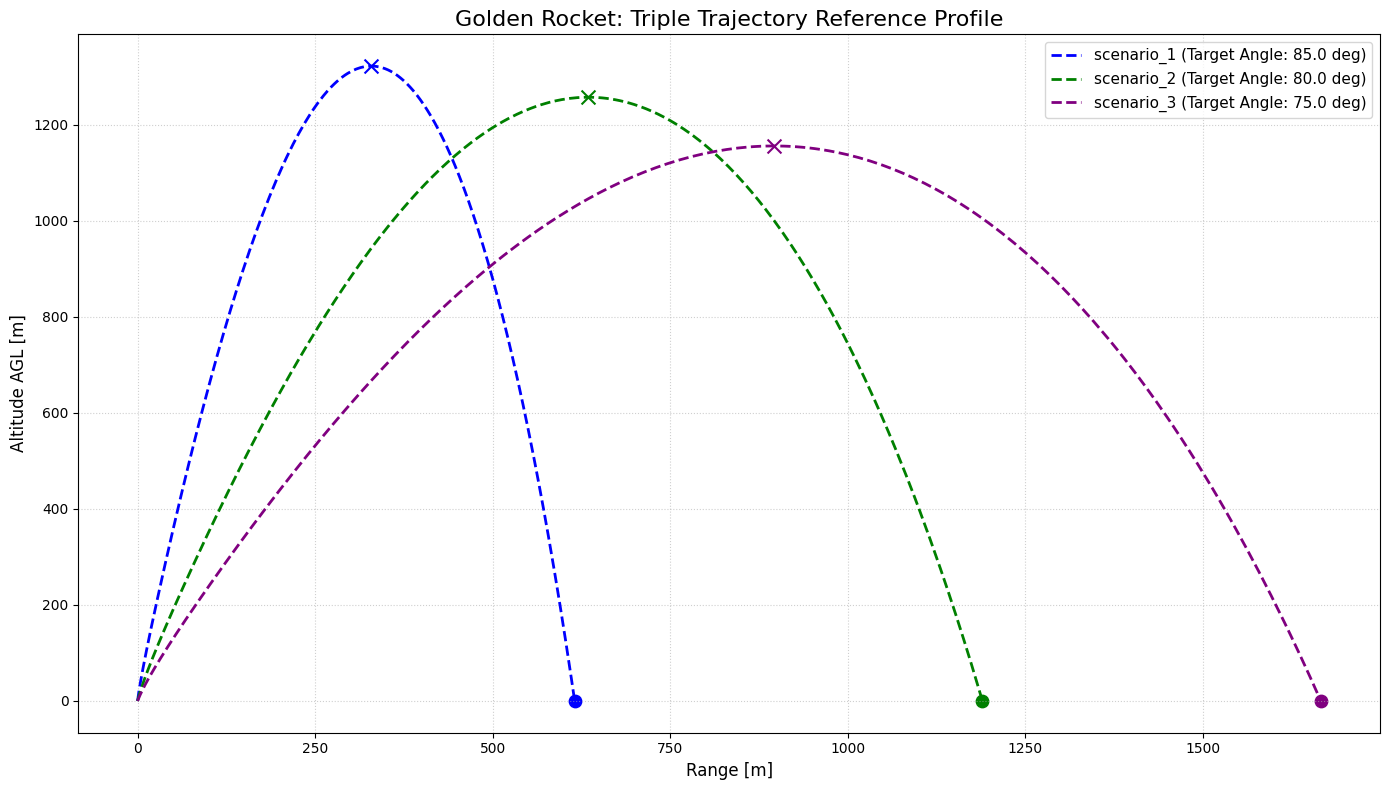


NEW GROUND TRUTH TARGETS :
SCENARIO        | ANGLE  | RANGE (m)    | APOGEE (m)   | TOF (s)    | TBO (s)   
-------------------------------------------------------------------------------------
scenario_1      | 85.0   | 615.6093     | 1322.3384    | 35.6024    | 4.5500    
scenario_2      | 80.0   | 1189.9028    | 1257.4659    | 34.7904    | 4.5500    
scenario_3      | 75.0   | 1666.5013    | 1155.9712    | 33.4512    | 4.5500    


In [13]:
# --- 2. GROUND TRUTH SIMULATION (Triple Trajectory) ---
print("\nStarting Multi-Trajectory simulation (Golden Rocket Ground Truth)...")

# Data structure to store results for the 3 launch scenarios
golden_results = {}
colors = ['blue', 'green', 'purple'] 

plt.figure(figsize=(14, 8))

# Iterate through each scenario defined in the configuration file
for i, (scen_name, scen_config) in enumerate(multi_trajectory_scenarios.items()):
    
    # Retrieve Fixed Angle for this specific scenario
    angle = scen_config['fixed_launch_angle']
    print(f"   Simulating {scen_name} (Launch Angle: {angle} deg)...")

    # FLIGHT SIMULATION
    # IMPORTANT: Use 'evaluator.env' to ensure consistency with the subsequent optimization phase.
    # Do not create a new Environment instance here; use the one with the pre-defined wind profile.
    flight = Flight(
        rocket=golden_rocket,
        environment=evaluator.env,
        rail_length=factory.rail_length,
        inclination=angle,
        heading=90, # East
        terminate_on_apogee=False
    )
    
    # Data Extraction
    alt = flight.z[:, 1] - evaluator.env.elevation
    ground_range = np.sqrt(flight.x[:, 1]**2 + flight.y[:, 1]**2)
    
    # Retrieve correct Time Burnout (TBO) from the motor
    # Note: Accessing the final time point of the thrust curve generated by the factory.
    tbo_val = flight.rocket.motor.burn_time[1]

    # Store key metrics for YAML configuration / Target setting
    golden_results[scen_name] = {
        'range': ground_range[-1],
        'apogee': flight.apogee - evaluator.env.elevation,
        'tof': flight.t_final,
        'tbo': tbo_val
    }

    # Plotting Trajectories
    plt.plot(ground_range, alt, color=colors[i], linestyle='--', linewidth=2, 
             label=f"{scen_name} (Target Angle: {angle} deg)")
    
    # Plot Markers (Apogee and Impact)
    idx_apogee = np.argmax(alt)
    plt.scatter(ground_range[idx_apogee], alt[idx_apogee], color=colors[i], s=100, marker='x')
    plt.scatter(ground_range[-1], 0, color=colors[i], s=80, marker='o')

# Chart Decoration
plt.title("Golden Rocket: Triple Trajectory Reference Profile", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitude AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- PRINT TARGET TABLE (FOR YAML UPDATE) ---
print("\nNEW GROUND TRUTH TARGETS :")
print(f"{'SCENARIO':<15} | {'ANGLE':<6} | {'RANGE (m)':<12} | {'APOGEE (m)':<12} | {'TOF (s)':<10} | {'TBO (s)':<10}")
print("-" * 85)

for name, data in golden_results.items():
    angle = multi_trajectory_scenarios[name]['fixed_launch_angle']
    print(f"{name:<15} | {angle:<6.1f} | {data['range']:<12.4f} | {data['apogee']:<12.4f} | {data['tof']:<10.4f} | {data['tbo']:<10.4f}")

In [14]:
# Global counter to track the number of objective function evaluations
call_counter = 0

def fitness_function_triple(params):
    """
    Objective function for the Multi-Objective (Triple Trajectory) optimization task.
    
    This function evaluates a single candidate rocket design against three distinct 
    launch scenarios (typically different launch angles) defined in the configuration.
    The total fitness is the aggregate error across all three trajectories.

    Args:
        params (dict): Dictionary of design variables (radius, length, fins, etc.)
                       generated by the optimizer.

    Returns:
        float: The calculated fitness score (lower is better). 
               Returns a high penalty value (10000.0) if the design is physically 
               invalid, unstable, or fails simulation.
    """
    global call_counter
    call_counter += 1
    
    # 1. Rocket Instantiation
    try:
        rocket = factory.create_rocket(params)
    except Exception:
        # Return penalty for geometrically impossible designs
        return 10000.0 
        
    # 2. Preliminary Stability Check (Safety)
    try:
        # If the rocket is statically unstable at launch (Mach 0), 
        # skip simulation to save computational resources.
        if rocket.static_margin(0) < 0:
            return 10000.0
    except:
        return 10000.0
        
    # 3. Multi-Scenario Simulation Loop
    results = {}
    
    # Iterate through scenarios loaded from YAML into the evaluator
    for scenario_name, config in evaluator.triple_scenarios.items():
        
        # The launch angle is FIXED per scenario (constraint), not optimized
        fixed_angle = config['fixed_launch_angle']
        
        # Execute Simulation
        flight_data = evaluator._simulate_flight(rocket, fixed_angle)
        
        # Fail-Fast: If any of the 3 simulations fail (crash/instability),
        # the entire design is considered invalid for the multi-objective task.
        if flight_data is None:
            return 10000.0
            
        results[scenario_name] = flight_data
    
    # 4. Calculate Total Fitness
    # Pass the dictionary of results to the evaluator with the 'triple' flag
    fitness = evaluator.evaluate(results, task_type='triple')
    
    # Periodic Logging
    if call_counter % 500 == 0:
        print(f"   Calls: {call_counter} | Current Fit: {fitness:.4f}")
        
    return fitness

print("Triple Trajectory Fitness Wrapper defined successfully.")

Triple Trajectory Fitness Wrapper defined successfully.


## ACO-R

In [15]:
print(f"Starting Multi-Trajectory ACO-R Optimization (Budget: {max_calls} calls)...")
start_time = time.time()

# 1. Algorithm Initialization
# Generates the initial random archive (costs k function calls)
optimizer = ContinuousACO(ACO_PARAMS_FILE, CONSTRAINTS_FILE)

# Note: Passing the specific multi-objective fitness function
optimizer.initialize(fitness_function_triple) 

# --- SAVE RANDOM START ---
# Retrieve the best solution found purely by random initialization
random_best_params, random_best_fit = optimizer.get_best_solution()

print(f"   Initial Fitness (Best Random - Sum of 3 scenarios): {random_best_fit:.4f}")
print("   Random Start parameters saved.")

# 2. Main Optimization Loop
best_fitness_history = []

# Call counter starts at k (size of the initial archive)
call_counter = optimizer.k 
iteration = 0

while call_counter < max_calls:
    iteration += 1
    
    # Execute one optimization step using the triple fitness function
    best_fit = optimizer.optimize_step(fitness_function_triple)
    best_fitness_history.append(best_fit)
    
    # Update counter (m ants generated per step)
    call_counter += optimizer.m
    
    # --- Logging: Print every 50 iterations ---
    if iteration % 50 == 0:
        print(f"   Calls: {call_counter:5d}/{max_calls} | Current Best Fitness: {best_fit:.4f}")

execution_time = time.time() - start_time
print(f"\nMulti-Trajectory Optimization completed in {execution_time:.2f} seconds.")
print(f"   Final Best Fitness: {optimizer.archive_F[0]:.4f}")

Starting Multi-Trajectory ACO-R Optimization (Budget: 4000 calls)...
   Initial Fitness (Best Random - Sum of 3 scenarios): 30.1925
   Random Start parameters saved.
   Calls:   250/4000 | Current Best Fitness: 15.4191
   Calls:   450/4000 | Current Best Fitness: 8.5055
   Calls: 500 | Current Fit: 36.9958
   Calls:   650/4000 | Current Best Fitness: 5.1213
   Calls:   850/4000 | Current Best Fitness: 1.8510
   Calls: 1000 | Current Fit: 20.0304
   Calls:  1050/4000 | Current Best Fitness: 1.8510
   Calls:  1250/4000 | Current Best Fitness: 1.7816
   Calls:  1450/4000 | Current Best Fitness: 1.1651
   Calls: 1500 | Current Fit: 30.9961
   Calls:  1650/4000 | Current Best Fitness: 1.1651
   Calls:  1850/4000 | Current Best Fitness: 1.1651
   Calls: 2000 | Current Fit: 37.4821
   Calls:  2050/4000 | Current Best Fitness: 0.9763
   Calls:  2250/4000 | Current Best Fitness: 0.9486
   Calls:  2450/4000 | Current Best Fitness: 0.9486
   Calls: 2500 | Current Fit: 31.0456
   Calls:  2650/4000

In [16]:
# ------------------------------------------------------------------------------
# POST-OPTIMIZATION VERIFICATION
# ------------------------------------------------------------------------------
# Contract:
# 1. Retrieve the globally best parameter set found by the optimizer.
# 2. Instantiate the physical rocket model corresponding to these parameters.
# 3. Sequentially simulate the rocket flight under the three specific
#    operational scenarios defined in the configuration (85, 80, 75 degrees).
# 4. Compare the simulated results against the Ground Truth targets to
#    validate the solution's accuracy.
# ------------------------------------------------------------------------------

# 1. Retrieve Optimal Parameters
best_params, best_score = optimizer.get_best_solution()

print(f"BEST SOLUTION FOUND (Total Fitness: {best_score:.4f})")
print("Optimized Design Parameters (Unified for all scenarios):")
for key, val in best_params.items():
    print(f"   {key}: {val:.4f}")

# 2. Create Optimized Rocket Model
best_rocket = factory.create_rocket(best_params)

# 3. Simulate Operational Scenarios
print("\nVerifying Performance across 3 Trajectories...")

# Iterate through scenarios defined in the evaluator (loaded from YAML)
for scen_name, scen_config in evaluator.triple_scenarios.items():
    
    # The launch angle is FIXED per scenario as a boundary condition
    fixed_angle = scen_config['fixed_launch_angle']
    target_vals = scen_config['target']
    
    print(f"\n   Simulating {scen_name} (Launch Angle: {fixed_angle} deg)")
    
    try:
        # Execute Flight Simulation
        flight = Flight(
            rocket=best_rocket,
            environment=evaluator.env, # Shared environment (includes wind profile)
            rail_length=factory.rail_length,
            inclination=fixed_angle,   # Scenario-specific angle
            heading=90,
            terminate_on_apogee=False
        )
        
        # Data Extraction
        # Calculate Apogee Altitude Above Ground Level (AGL)
        real_apogee = flight.apogee - evaluator.env.elevation
        
        # Calculate Euclidean ground range from launch point to impact point
        real_range = np.sqrt(flight.x_impact**2 + flight.y_impact**2)
        
        # Error Calculation for quick validation
        err_apo = real_apogee - target_vals['apogee']
        err_rng = real_range - target_vals['range']
        
        # Output Metrics
        print(f"      Apogee: {real_apogee:.2f} m  (Target: {target_vals['apogee']:.0f} m | Err: {err_apo:+.1f})")
        print(f"      Range:  {real_range:.2f} m   (Target: {target_vals['range']:.0f} m  | Err: {err_rng:+.1f})")
        print(f"      TOF:    {flight.t_final:.2f} s")
        
    except Exception as e:
        print(f"      Error during simulation: {e}")

BEST SOLUTION FOUND (Total Fitness: 0.6948)
Optimized Design Parameters (Unified for all scenarios):
   radius: 0.0608
   body_length: 2.3904
   nose_length: 0.4118
   fin_span: 0.2488
   fin_root_chord: 0.2780
   fin_tip_chord: 0.1256
   fin_sweep_angle: 38.6536
   fin_distance_from_base: 0.0000
   total_impulse: 3253.8251
   burn_time: 4.4490
   launch_angle: 84.9038

Verifying Performance across 3 Trajectories...

   Simulating scenario_1 (Launch Angle: 85.0 deg)
      Apogee: 1323.00 m  (Target: 1322 m | Err: +0.7)
      Range:  616.08 m   (Target: 616 m  | Err: +0.5)
      TOF:    35.56 s

   Simulating scenario_2 (Launch Angle: 80.0 deg)
      Apogee: 1257.62 m  (Target: 1258 m | Err: +0.1)
      Range:  1189.71 m   (Target: 1190 m  | Err: -0.2)
      TOF:    34.74 s

   Simulating scenario_3 (Launch Angle: 75.0 deg)
      Apogee: 1156.02 m  (Target: 1156 m | Err: +0.0)
      Range:  1663.20 m   (Target: 1666 m  | Err: -3.3)
      TOF:    33.39 s


In [17]:
# ------------------------------------------------------------------------------
# DATA REGENERATION FOR MULTI-TRAJECTORY PLOTTING
# ------------------------------------------------------------------------------
# Contract:
# 1. Instantiate the final optimized rocket model and the reference Golden Rocket.
# 2. Iterate through all defined operational scenarios (Triple Trajectory).
# 3. Simulate flights for both rockets under identical environmental conditions
#    (specifically including wind effects defined in the evaluator).
# 4. Aggregate flight objects and target metadata into a structured list 'scenarios_data'
#    for subsequent visualization and analysis.
# ------------------------------------------------------------------------------

# 1. Rocket Instantiation
# Create the rocket object based on the best parameters found by the optimizer
final_rocket = factory.create_rocket(best_params)
# Re-create the reference Golden Rocket based on configuration
golden_rocket = factory.create_rocket(missile_config['golden_rocket'])

scenarios_data = []

print("Generating flight data for 3 scenarios...")

# 2. Simulation Loop
# Iterate over the scenarios defined in the evaluator (loaded from YAML)
for key, val in evaluator.triple_scenarios.items():
    angle = val['fixed_launch_angle']
    target = val['target']
    
    # A. Simulate OPTIMIZED Rocket Flight
    # Uses the evaluator's environment to ensure consistent wind conditions
    flight_opt = Flight(
        rocket=final_rocket, 
        environment=evaluator.env, 
        rail_length=factory.rail_length, 
        inclination=angle, 
        heading=90, 
        terminate_on_apogee=False
    )
    
    # B. Simulate GOLDEN Rocket Flight (Reference)
    # Uses the same environment and angle to establish the baseline trajectory
    flight_golden = Flight(
        rocket=golden_rocket, 
        environment=evaluator.env, 
        rail_length=factory.rail_length, 
        inclination=angle, 
        heading=90, 
        terminate_on_apogee=False
    )
    
    # 3. Data Aggregation
    # Store flight objects and metadata for plotting
    scenarios_data.append({
        "name": key,
        "angle": angle,
        "opt_flight": flight_opt,
        "golden_flight": flight_golden,
        "target_vals": target
    })

print(f"Data ready for {len(scenarios_data)} scenarios.")

Generating flight data for 3 scenarios...
Data ready for 3 scenarios.


Generating Unified Plot...


/tmp/ipykernel_32341/2893411833.py:58: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(r_opt[idx_opt], z_opt[idx_opt], color=color, marker='x', s=100, edgecolors='black', zorder=6)


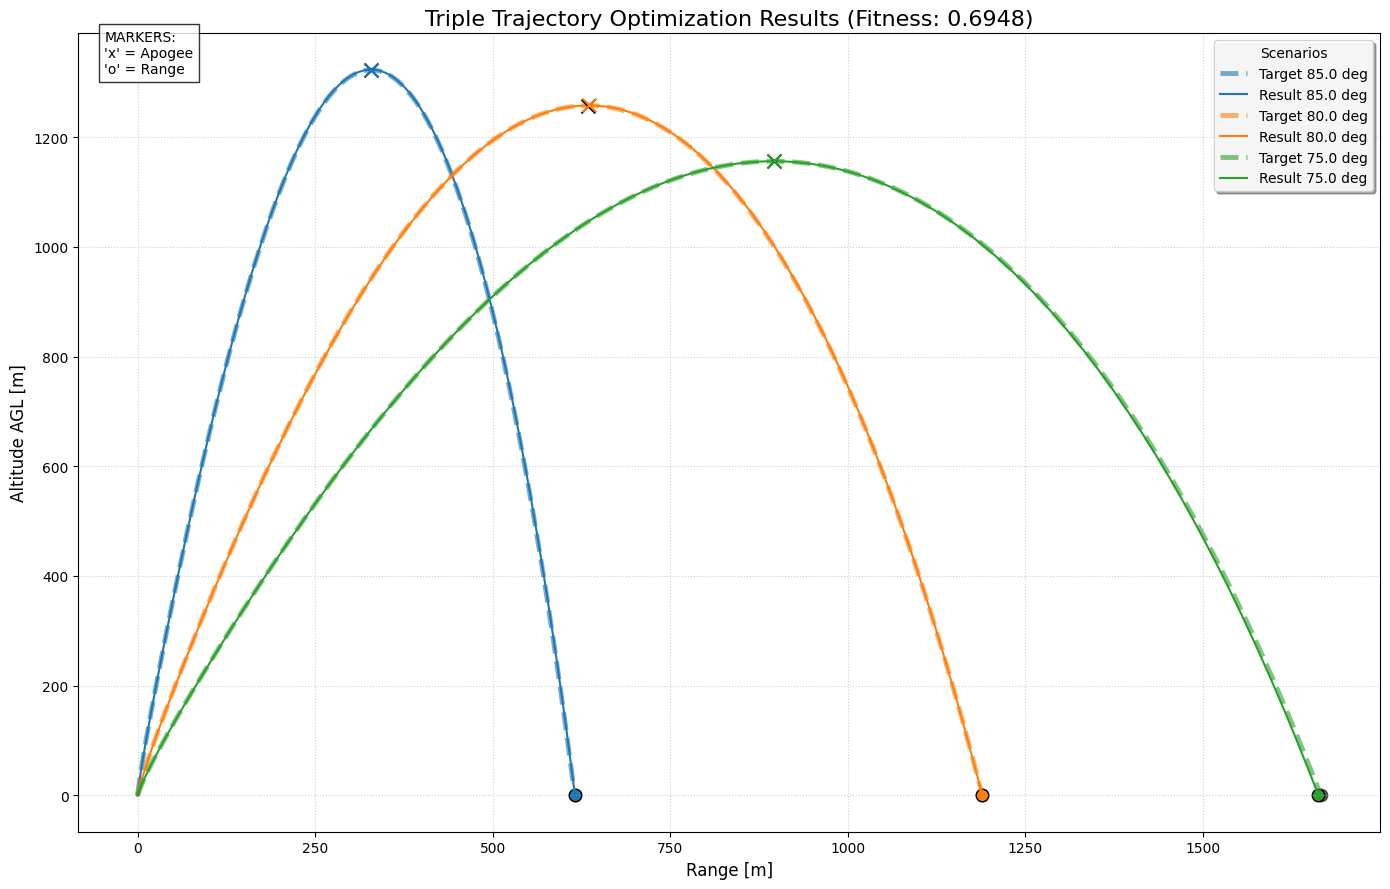

In [18]:
# ------------------------------------------------------------------------------
# UNIFIED TRAJECTORY PLOT GENERATION
# ------------------------------------------------------------------------------
# Contract:
# 1. Iterate through the 'scenarios_data' list containing flight objects for both
#    the Target (Golden) and Optimized (ACO) rockets.
# 2. Extract spatial data (Range and Altitude AGL).
# 3. Plot trajectories on a single figure to visualize multi-objective coverage.
#    - Target: Dashed lines (background).
#    - Result: Solid lines (foreground).
# 4. Highlight critical points (Apogee and Impact) using distinct markers.
# ------------------------------------------------------------------------------

# Setup Single Figure
plt.figure(figsize=(14, 9))

# Define distinct colors for the 3 scenarios (Blue, Orange, Green)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

# Reference elevation for AGL calculation
base_elevation = evaluator.env.elevation

print("Generating Unified Plot...")

for i, data in enumerate(scenarios_data):
    color = colors[i]
    angle = data['angle']
    name = data['name']
    
    # --- Extract Target Data ---
    fg = data['golden_flight']
    # Calculate Euclidean ground range
    r_tgt = np.sqrt(fg.x[:,1]**2 + fg.y[:,1]**2)
    # Calculate Altitude Above Ground Level
    z_tgt = fg.z[:,1] - base_elevation
    
    # --- Extract Optimized Data ---
    fo = data['opt_flight']
    r_opt = np.sqrt(fo.x[:,1]**2 + fo.y[:,1]**2)
    z_opt = fo.z[:,1] - base_elevation
    
    # --- Plotting Lines ---
    # Target: Dashed line, thicker but transparent
    plt.plot(r_tgt, z_tgt, color=color, linestyle='--', linewidth=3.5, alpha=0.6,
             label=f'Target {angle} deg')
    
    # Optimized: Solid line, standard width
    plt.plot(r_opt, z_opt, color=color, linestyle='-', linewidth=1.5,
             label=f'Result {angle} deg')
    
    # --- Apogee Markers ---
    idx_tgt = np.argmax(z_tgt)
    idx_opt = np.argmax(z_opt)
    
    # Target Apogee: Black Cross
    plt.scatter(r_tgt[idx_tgt], z_tgt[idx_tgt], color="black", marker='x', s=100, zorder=5)
    # Result Apogee: Colored Cross with edge
    plt.scatter(r_opt[idx_opt], z_opt[idx_opt], color=color, marker='x', s=100, edgecolors='black', zorder=6)
    
    # --- Impact/Range Markers ---
    # Target Impact: Black Circle (transparent)
    plt.scatter(r_tgt[-1], 0, color="black", marker='o', s=80, alpha=0.6)
    # Result Impact: Colored Circle
    plt.scatter(r_opt[-1], 0, color=color, marker='o', s=80, edgecolors='black')

# --- Chart Decorations ---
plt.title(f"Triple Trajectory Optimization Results (Fitness: {best_score:.4f})", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitude AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Legend
plt.legend(loc='upper right', framealpha=0.9, shadow=True, fontsize=10, title="Scenarios")

# Marker Legend Annotation
plt.text(0.02, 0.95, "MARKERS:\n'x' = Apogee\n'o' = Range", 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [19]:
# ------------------------------------------------------------------------------
# TRIPLE TRAJECTORY RESULTS SUMMARY TABLE
# ------------------------------------------------------------------------------
# Contract:
# 1. Dynamically build column headers based on the scenarios present in 'scenarios_data'.
# 2. Extract performance metrics (Apogee, Range, TOF, TBO) for both Target and Optimized flights.
# 3. Calculate residuals (Difference = Optimized - Target).
# 4. Aggregate data into a pandas DataFrame for display and export.
# ------------------------------------------------------------------------------

# 1. Define Column Headers
headers = ["Metric"]
for data in scenarios_data:
    angle = int(data['angle'])
    headers.append(f"Target ({angle} deg)")
    headers.append(f"ACO-R ({angle} deg)")
    headers.append(f"Diff ({angle} deg)")

# 2. Prepare Data Rows
row_apogee = ["Apogee (m)"]
row_range  = ["Range (m)"]
row_tof    = ["TOF (s)"]
row_tbo    = ["TBO (s)"]

for data in scenarios_data:
    # --- Data Extraction ---
    flight_opt = data['opt_flight']
    targets = data['target_vals']
    
    # Optimized Values (ACO)
    opt_apogee = flight_opt.apogee - evaluator.env.elevation
    opt_range = np.sqrt(flight_opt.x[:,1][-1]**2 + flight_opt.y[:,1][-1]**2)
    opt_tof = flight_opt.t_final
    opt_tbo = best_params['burn_time'] # Constant across scenarios for the same rocket
    
    # Target Values (Golden)
    tgt_apogee = targets['apogee']
    tgt_range = targets['range']
    tgt_tof = targets['flight_time']
    tgt_tbo = targets['burn_time']
    
    # --- Populate Rows (Target, Result, Difference) ---
    # Apogee
    row_apogee.extend([tgt_apogee, opt_apogee, (opt_apogee - tgt_apogee)])
    # Range
    row_range.extend([tgt_range, opt_range, (opt_range - tgt_range)])
    # Time of Flight
    row_tof.extend([tgt_tof, opt_tof, (opt_tof - tgt_tof)])
    # Time Burnout
    row_tbo.extend([tgt_tbo, opt_tbo, (opt_tbo - tgt_tbo)])

# 3. Create DataFrame
df_flat = pd.DataFrame([row_apogee, row_range, row_tof, row_tbo], columns=headers)

# 4. Formatting and Display
pd.options.display.float_format = '{:,.2f}'.format

print("\nFINAL SUMMARY TABLE (Triple Trajectory)")
print("="*100)
display(df_flat)

# Optional Export
# df_flat.to_csv("../results/triple_trajectory/ACO-R_results_trajectories.csv", index=False)


FINAL SUMMARY TABLE (Triple Trajectory)


,Metric,Target (85 deg),ACO-R (85 deg),Diff (85 deg),Target (80 deg),ACO-R (80 deg),Diff (80 deg),Target (75 deg),ACO-R (75 deg),Diff (75 deg)
0,Apogee (m),"1,322.30","1,323.00",0.70,"1,257.50","1,257.62",0.12,"1,156.00","1,156.02",0.02
1,Range (m),615.60,616.08,0.48,"1,189.90","1,189.71",-0.19,"1,666.50","1,663.20",-3.30
2,TOF (s),35.60,35.56,-0.04,34.80,34.74,-0.06,33.50,33.39,-0.11
3,TBO (s),4.50,4.45,-0.05,4.50,4.45,-0.05,4.50,4.45,-0.05


In [20]:
def draw_detailed_rocket_3d(params):
    """
    Advanced 3D visualization of the rocket including internal details:
    - Transparent fuselage
    - Motor Grain (internal)
    - External Nozzle
    - Payload (Warhead)
    - Center of Gravity (CG) marker

    The geometry and mass distribution logic replicates the RocketFactory class
    to ensure visual consistency with the physical model.
    """
    # ==========================================
    # 1. GEOMETRIC AND PHYSICAL LOGIC
    # ==========================================
    
    # --- Base Geometry ---
    r = params['radius']
    L_nose = params['nose_length']
    L_body = params['body_length']
    L_total = L_nose + L_body
    
    # --- Fins Geometry ---
    root_chord = params['fin_root_chord']
    tip_chord = params['fin_tip_chord']
    safe_tip_chord = min(tip_chord, root_chord)
    span = params['fin_span']
    sweep_angle = params['fin_sweep_angle']
    dist_base = params['fin_distance_from_base']
    
    # Derived calculations
    sweep_len = span * np.tan(np.radians(sweep_angle))
    fin_root_le_x = L_total - dist_base - root_chord
    
    # --- Motor and Nozzle ---
    grain_len = L_body * 0.4
    motor_x_start = L_total - grain_len
    motor_radius = r * 0.75
    
    # Nozzle geometry (derived from factory assumption)
    nozzle_exit_r = r * 0.35
    nozzle_base_r = r * 0.55
    nozzle_len = r * 1.2
    
    # --- Payload ---
    payload_x = L_nose * 0.5
    
    # --- CG Estimation (Simplified Factory Logic) ---
    rho = 2000.0; wall = 0.003
    
    # Component Masses and CGs
    m_nose = (np.pi * r * np.sqrt(r**2 + L_nose**2)) * wall * rho
    cg_nose = L_nose * 0.666
    
    m_body = (2 * np.pi * r * L_body) * wall * rho
    cg_body = L_nose + (L_body * 0.5)
    
    fin_area = (root_chord + safe_tip_chord) / 2 * span
    m_fins = (fin_area * 0.005 * 1800) * 4
    cg_fins = fin_root_le_x + (root_chord * 0.5)
    
    m_payload = 1.0
    
    # Motor Mass (Total at Liftoff)
    m_prop = params['total_impulse'] / (210 * 9.81)
    m_motor_tot = m_prop * 1.3
    cg_motor = L_total - (grain_len / 2)
    
    # System CG Calculation
    total_mass = m_nose + m_body + m_fins + m_payload + m_motor_tot
    total_moment = (m_nose*cg_nose + m_body*cg_body + m_fins*cg_fins + 
                    m_payload*payload_x + m_motor_tot*cg_motor)
    cg_pos = total_moment / total_mass

    # ==========================================
    # 2. 3D RENDERING
    # ==========================================
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Mesh resolution
    N_radial = 40 
    theta = np.linspace(0, 2 * np.pi, N_radial)

    # --- A. FUSELAGE (Transparent) ---
    x_body = np.linspace(L_nose, L_total, 20)
    theta_g, x_g = np.meshgrid(theta, x_body)
    y_body = r * np.cos(theta_g)
    z_body = r * np.sin(theta_g)
    ax.plot_surface(x_g, y_body, z_body, color='azure', alpha=0.2, edgecolor='gray', linewidth=0.1)

    # --- B. NOSE CONE ---
    x_nose_arr = np.linspace(0, L_nose, 20)
    theta_gn, x_gn = np.meshgrid(theta, x_nose_arr)
    # Power series profile for aerodynamic look
    r_loc = r * (x_gn / L_nose)**0.75
    y_n = r_loc * np.cos(theta_gn)
    z_n = r_loc * np.sin(theta_gn)
    ax.plot_surface(x_gn, y_n, z_n, color='lightgray', alpha=0.6, edgecolor='none')

    # --- C. MOTOR GRAIN (Internal) ---
    x_mot = np.linspace(motor_x_start, L_total, 10)
    theta_gm, x_gm = np.meshgrid(theta, x_mot)
    y_mot = motor_radius * np.cos(theta_gm)
    z_mot = motor_radius * np.sin(theta_gm)
    ax.plot_surface(x_gm, y_mot, z_mot, color='firebrick', alpha=0.8, shade=True)

    # --- D. NOZZLE (External) ---
    x_noz = np.linspace(L_total, L_total + nozzle_len, 10)
    theta_noz, x_noz_grid = np.meshgrid(theta, x_noz)
    
    # Linear interpolation for conical nozzle shape
    pct = (x_noz_grid - L_total) / nozzle_len
    r_current_noz = nozzle_base_r * (1 - pct) + nozzle_exit_r * pct
    
    y_noz = r_current_noz * np.cos(theta_noz)
    z_noz = r_current_noz * np.sin(theta_noz)
    
    ax.plot_surface(x_noz_grid, y_noz, z_noz, color='#222222', alpha=1.0, shade=True)

    # --- E. PAYLOAD (Warhead) ---
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    sphere_r = r * 0.6
    x_pay = payload_x + sphere_r * np.cos(u) * np.sin(v)
    y_pay = sphere_r * np.sin(u) * np.sin(v)
    z_pay = sphere_r * np.cos(v)
    ax.plot_surface(x_pay, y_pay, z_pay, color='limegreen', alpha=0.9)

    # --- F. FINS ---
    # Define fin points in 2D (x, r)
    p_root_le = np.array([fin_root_le_x, r])
    p_tip_le  = np.array([fin_root_le_x + sweep_len, r + span])
    p_tip_te  = np.array([fin_root_le_x + sweep_len + safe_tip_chord, r + span])
    p_root_te = np.array([fin_root_le_x + root_chord, r])
    
    fin_colors = ['darkred', 'red', 'darkred', 'red']
    
    # Rotate and place 4 fins
    for i, angle_deg in enumerate([0, 90, 180, 270]):
        rad = np.radians(angle_deg)
        c, s = np.cos(rad), np.sin(rad)
        
        # Rotation helper
        def rot(x, rd): return [x, rd*c, rd*s]

        pts = [rot(p[0], p[1]) for p in [p_root_le, p_tip_le, p_tip_te, p_root_te]]
        poly = Poly3DCollection([pts], alpha=0.9, facecolor=fin_colors[i], edgecolor='black')
        ax.add_collection3d(poly)

    # --- G. CG MARKER ---
    ax.scatter(cg_pos, 0, 0, color='black', s=200, marker='+', linewidth=3, label='Center of Gravity')
    # Vertical reference line for CG
    ax.plot([cg_pos, cg_pos], [0, 0], [0, r*2.5], 'k--', linewidth=1)
    ax.text(cg_pos, 0, r*2.8, "CG", color='black', fontsize=12, weight='bold', ha='center')

    # --- GRAPHICS SETUP ---
    ax.set_xlabel('Length (m)')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"3D ACO-R + LS optimized for triple-trajectory Rocket Visualization \n(L={L_total:.2f}m, D={r*2*1000:.0f}mm)", fontsize=14)
    
    # Limits & Aspect Ratio
    limits = np.array([0, L_total + nozzle_len])
    max_range = np.ptp(limits)
    mid_x = np.mean(limits)
    
    ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
    ax.set_ylim(-max_range/6, max_range/6)
    ax.set_zlim(-max_range/6, max_range/6)
    
    # Initial view angle
    ax.view_init(elev=20, azim=-60)
    
    # Enforce equal aspect ratio to avoid distortion
    ax.set_box_aspect((3, 1, 1))
    
    # Custom Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='lightgray', lw=4, label='Fuselage'),
        Line2D([0], [0], color='firebrick', lw=4, label='Motor Grain'),
        Line2D([0], [0], color='black', lw=4, label='Nozzle'),
        Line2D([0], [0], color='limegreen', marker='o', lw=0, label='Payload'),
        Line2D([0], [0], color='black', marker='+', lw=0, markersize=10, label='CG')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

In [21]:
#draw_detailed_rocket_3d(best_params)

## ACO-R + LS

In [22]:
# ------------------------------------------------------------------------------
# HYBRID OPTIMIZATION PHASE: LOCAL SEARCH FINE-TUNING
# ------------------------------------------------------------------------------
# Contract:
# 1. Load the Nelder-Mead optimization module.
# 2. Initialize the Local Search engine using parameters from 'ACO_params.yaml'.
# 3. Extract the best solution found by the global ACO-R optimizer to use as
#    the starting vertex for the simplex.
# 4. Execute the Nelder-Mead search using the multi-objective fitness function
#    (fitness_function_triple) to refine the solution across all scenarios.
# 5. Parse results, calculate performance improvement, and update global state.
# ------------------------------------------------------------------------------

try:
    from optimizer.nelder_mead import NelderMeadSimplex
    print("Nelder-Mead module loaded successfully.")
except ImportError:
    print("Error: Nelder-Mead module not found.")

print("\nStarting Multi-Trajectory Fine Tuning with Local Search (Nelder-Mead)...")
ls_start_time = time.time()

# 1. Configuration
# Retrieve Local Search settings (budget, tolerance, step size) from global config
ls_config = aco_config['local_search']
ls_engine = NelderMeadSimplex(optimizer, ls_config)

# 2. Initialization
# The starting point is the best vector currently in the ACO archive
aco_best_vector = optimizer.archive_X[0]
aco_best_fitness = optimizer.archive_F[0]

print(f"   Input Fitness (from ACO): {aco_best_fitness:.5f}")

# 3. Execution
# Pass the multi-objective fitness function to evaluate 3 scenarios simultaneously.
# Note: This continues to increment the global 'call_counter' within the wrapper.
ls_best_vector, ls_best_fitness = ls_engine.search(aco_best_vector, fitness_function_triple)

# 4. Result Parsing
# Map the optimized vector back to the parameter dictionary names
ls_best_params = dict(zip(optimizer.var_names, ls_best_vector))

ls_time = time.time() - ls_start_time
print(f"Local Search completed in {ls_time:.2f} s.")
print(f"   Initial Fitness (ACO):     {aco_best_fitness:.5f}")
print(f"   Final Fitness (ACO+LS):    {ls_best_fitness:.5f}")

# Calculate Improvement Percentage
if aco_best_fitness > 0:
    improvement = ((aco_best_fitness - ls_best_fitness) / aco_best_fitness) * 100
    print(f"   Improvement: {improvement:.2f}%")
else:
    print(f"   Fitness is already zero (Ideal case).")

# Update global variables for subsequent plotting/analysis cells
# best_params = ls_best_params
# best_score = ls_best_fitness

Nelder-Mead module loaded successfully.

Starting Multi-Trajectory Fine Tuning with Local Search (Nelder-Mead)...
   Input Fitness (from ACO): 0.69484
   Calls: 4500 | Current Fit: 0.6739
Local Search completed in 270.36 s.
   Initial Fitness (ACO):     0.69484
   Final Fitness (ACO+LS):    0.64800
   Improvement: 6.74%


In [23]:
print("\n" + "="*50)
print(f"BEST SOLUTION FOUND (ACO-R + Local Search)")
print("="*50)
print(f"Final Fitness: {ls_best_fitness:.6f}")
print("-" * 50)
print(f"{'PARAMETER':<25} | {'VALUE':<15}")
print("-" * 50)

for key, val in ls_best_params.items():
    print(f"{key:<25} | {val:.4f}")

print("="*50)


BEST SOLUTION FOUND (ACO-R + Local Search)
Final Fitness: 0.647997
--------------------------------------------------
PARAMETER                 | VALUE          
--------------------------------------------------
radius                    | 0.0608
body_length               | 2.3904
nose_length               | 0.4114
fin_span                  | 0.2488
fin_root_chord            | 0.2781
fin_tip_chord             | 0.1256
fin_sweep_angle           | 38.8959
fin_distance_from_base    | 0.0003
total_impulse             | 3253.6587
burn_time                 | 4.4506
launch_angle              | 84.9871


In [24]:
final_rocket = factory.create_rocket(ls_best_params)
golden_rocket = factory.create_rocket(missile_config['golden_rocket'])

scenarios_data = []

for key, val in evaluator.triple_scenarios.items():
    angle = val['fixed_launch_angle']
    target = val['target']
    
    flight_opt = Flight(
        rocket=final_rocket, 
        environment=evaluator.env, 
        rail_length=factory.rail_length, 
        inclination=angle, 
        heading=90, 
        terminate_on_apogee=False
    )
    
    flight_golden = Flight(
        rocket=golden_rocket, 
        environment=evaluator.env, 
        rail_length=factory.rail_length, 
        inclination=angle, 
        heading=90, 
        terminate_on_apogee=False
    )
    
    scenarios_data.append({
        "name": key,
        "angle": angle,
        "opt_flight": flight_opt,
        "golden_flight": flight_golden,
        "target_vals": target
    })

Generating Unified Plot (ACO+LS Results)...


/tmp/ipykernel_32341/4194740199.py:62: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(r_opt[idx_opt], z_opt[idx_opt], color=color, marker='x', s=100, edgecolors='black', zorder=6)


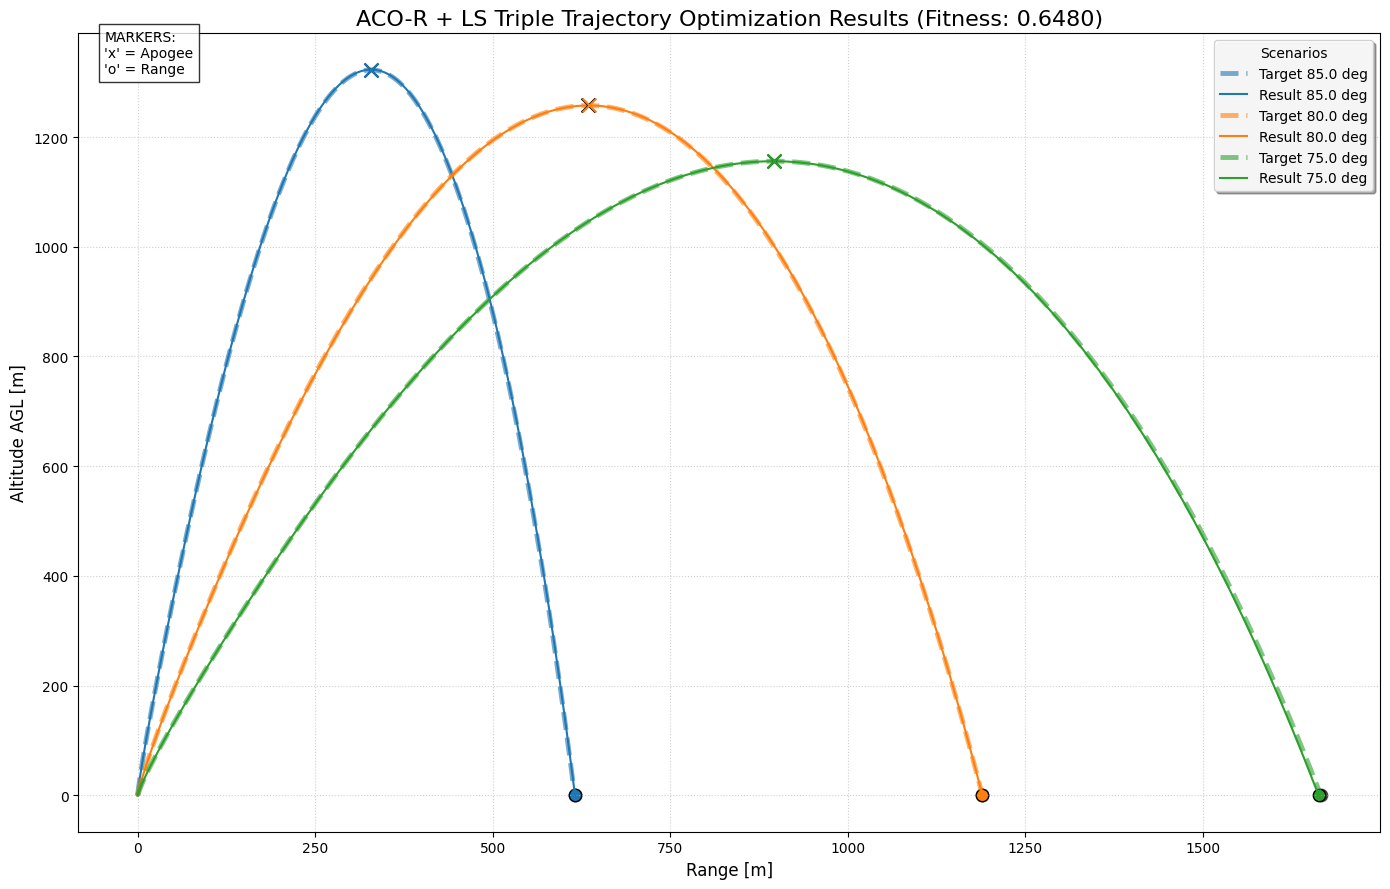

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------------------
# TRIPLE TRAJECTORY VISUALIZATION (ACO-R + LOCAL SEARCH)
# ------------------------------------------------------------------------------
# Contract:
# 1. Initialize a unified figure for comparative plotting.
# 2. Iterate through the 'scenarios_data' list containing flight simulations
#    for both the Target (Golden) and Optimized (ACO+LS) rockets.
# 3. Extract flight path data (Ground Range vs. Altitude AGL).
# 4. Plot trajectories overlaying the optimized result against the target.
#    - Target: Dashed line (Background context).
#    - Result: Solid line (Primary focus).
# 5. Mark critical performance points:
#    - 'x': Apogee (Max Altitude).
#    - 'o': Impact Point (Max Range).
# ------------------------------------------------------------------------------

# --- Figure Setup ---
plt.figure(figsize=(14, 9))

# Distinct colors for the 3 scenarios (Blue, Orange, Green)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

# Base elevation for AGL calculation
base_elevation = evaluator.env.elevation

print("Generating Unified Plot (ACO+LS Results)...")

for i, data in enumerate(scenarios_data):
    color = colors[i]
    angle = data['angle']
    name = data['name']
    
    # --- Extract Target Data (Golden Rocket) ---
    fg = data['golden_flight']
    r_tgt = np.sqrt(fg.x[:,1]**2 + fg.y[:,1]**2)
    z_tgt = fg.z[:,1] - base_elevation
    
    # --- Extract Optimized Data (ACO + LS) ---
    fo = data['opt_flight']
    r_opt = np.sqrt(fo.x[:,1]**2 + fo.y[:,1]**2)
    z_opt = fo.z[:,1] - base_elevation
    
    # --- Plot Trajectories ---
    # Target: Dashed, slightly transparent to serve as reference
    plt.plot(r_tgt, z_tgt, color=color, linestyle='--', linewidth=3.5, alpha=0.6,
             label=f'Target {angle} deg')
    
    # Optimized: Solid, thinner line for precision visibility
    plt.plot(r_opt, z_opt, color=color, linestyle='-', linewidth=1.5,
             label=f'Result {angle} deg')
    
    # --- Plot Apogee Markers (Altitude Error) ---
    idx_tgt = np.argmax(z_tgt)
    idx_opt = np.argmax(z_opt)
    
    # Target: Black Cross
    plt.scatter(r_tgt[idx_tgt], z_tgt[idx_tgt], color="black", marker='x', s=100, zorder=5)
    # Result: Colored Cross with edge
    plt.scatter(r_opt[idx_opt], z_opt[idx_opt], color=color, marker='x', s=100, edgecolors='black', zorder=6)
    
    # --- Plot Impact Markers (Range Error) ---
    # Target: Black Circle (transparent)
    plt.scatter(r_tgt[-1], 0, color="black", marker='o', s=80, alpha=0.6)
    # Result: Colored Circle
    plt.scatter(r_opt[-1], 0, color=color, marker='o', s=80, edgecolors='black')

# --- Chart Decorations ---
plt.title(f"ACO-R + LS Triple Trajectory Optimization Results (Fitness: {ls_best_fitness:.4f})", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitude AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Legend Configuration
plt.legend(loc='upper right', framealpha=0.9, shadow=True, fontsize=10, title="Scenarios")

# Marker Explanation Box
plt.text(0.02, 0.95, "MARKERS:\n'x' = Apogee\n'o' = Range", 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [26]:
headers = ["Metric"]
for data in scenarios_data:
    angle = int(data['angle'])
    headers.append(f"Target ({angle}°)")
    headers.append(f"ACO-R ({angle}°)")
    headers.append(f"Diff ({angle}°)")


row_apogee = ["Apogee (m)"]
row_range  = ["Range (m)"]
row_tof    = ["TOF (s)"]
row_tbo    = ["TBO (s)"]

for data in scenarios_data:
    flight_opt = data['opt_flight']
    targets = data['target_vals']
    
    #  (ACO)
    opt_apogee = flight_opt.apogee - evaluator.env.elevation
    opt_range = np.sqrt(flight_opt.x[:,1][-1]**2 + flight_opt.y[:,1][-1]**2)
    opt_tof = flight_opt.t_final
    opt_tbo = best_params['burn_time'] 
    
    tgt_apogee = targets['apogee']
    tgt_range = targets['range']
    tgt_tof = targets['flight_time']
    tgt_tbo = targets['burn_time']
    
    # Apogeo
    row_apogee.extend([tgt_apogee, opt_apogee, (opt_apogee - tgt_apogee)])
    # Range
    row_range.extend([tgt_range, opt_range, (opt_range - tgt_range)])
    # TOF
    row_tof.extend([tgt_tof, opt_tof, (opt_tof - tgt_tof)])
    # TBO
    row_tbo.extend([tgt_tbo, opt_tbo, (opt_tbo - tgt_tbo)])


df_flat = pd.DataFrame([row_apogee, row_range, row_tof, row_tbo], columns=headers)

pd.options.display.float_format = '{:,.2f}'.format

print("\n📊 TABELLA RIASSUNTIVA FINALE (Triple Trajectory)")
print("="*100)
display(df_flat)

#df_flat.to_csv("../results/triple_trajectory/ACO-R_LS_results_trajectories.csv", index=False)


📊 TABELLA RIASSUNTIVA FINALE (Triple Trajectory)


,Metric,Target (85°),ACO-R (85°),Diff (85°),Target (80°),ACO-R (80°),Diff (80°),Target (75°),ACO-R (75°),Diff (75°)
0,Apogee (m),"1,322.30","1,322.84",0.54,"1,257.50","1,257.50",-0.00,"1,156.00","1,155.88",-0.12
1,Range (m),615.60,616.15,0.55,"1,189.90","1,189.88",-0.02,"1,666.50","1,663.41",-3.09
2,TOF (s),35.60,35.56,-0.04,34.80,34.74,-0.06,33.50,33.39,-0.11
3,TBO (s),4.50,4.45,-0.05,4.50,4.45,-0.05,4.50,4.45,-0.05


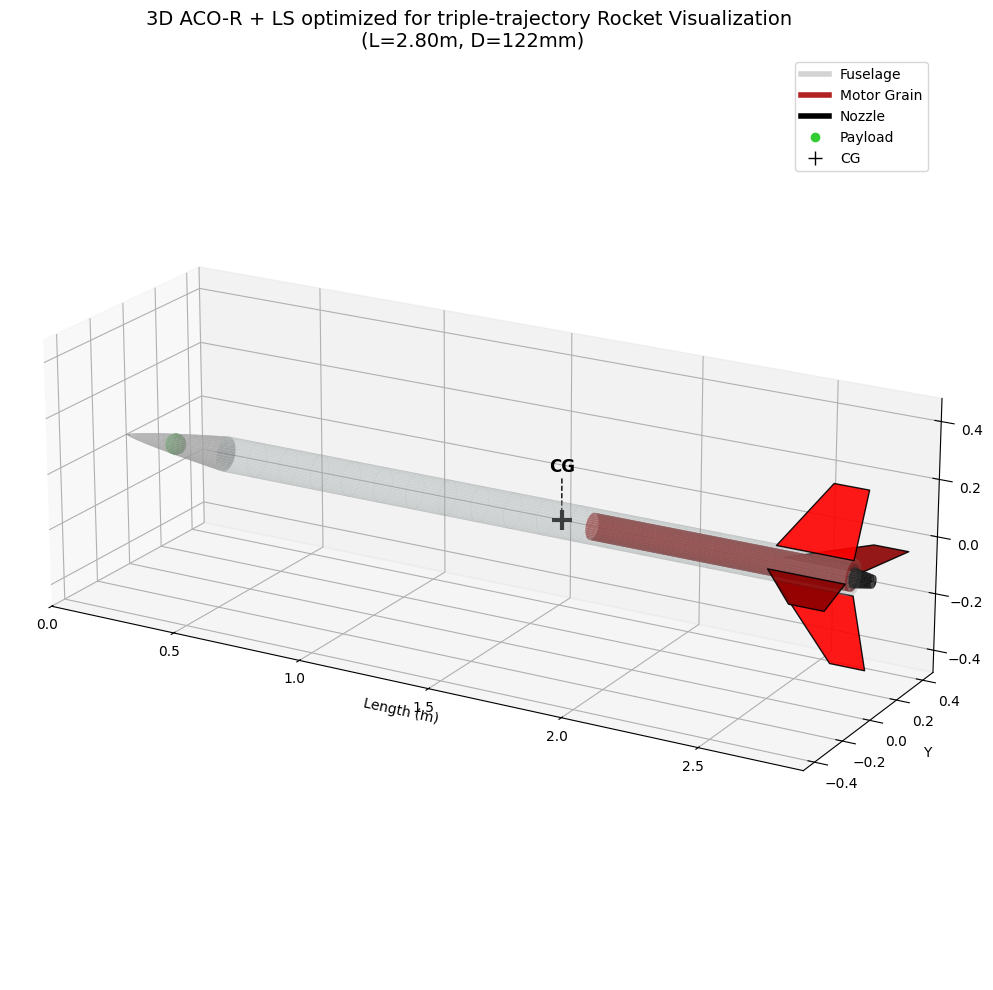

In [27]:
draw_detailed_rocket_3d(ls_best_params)

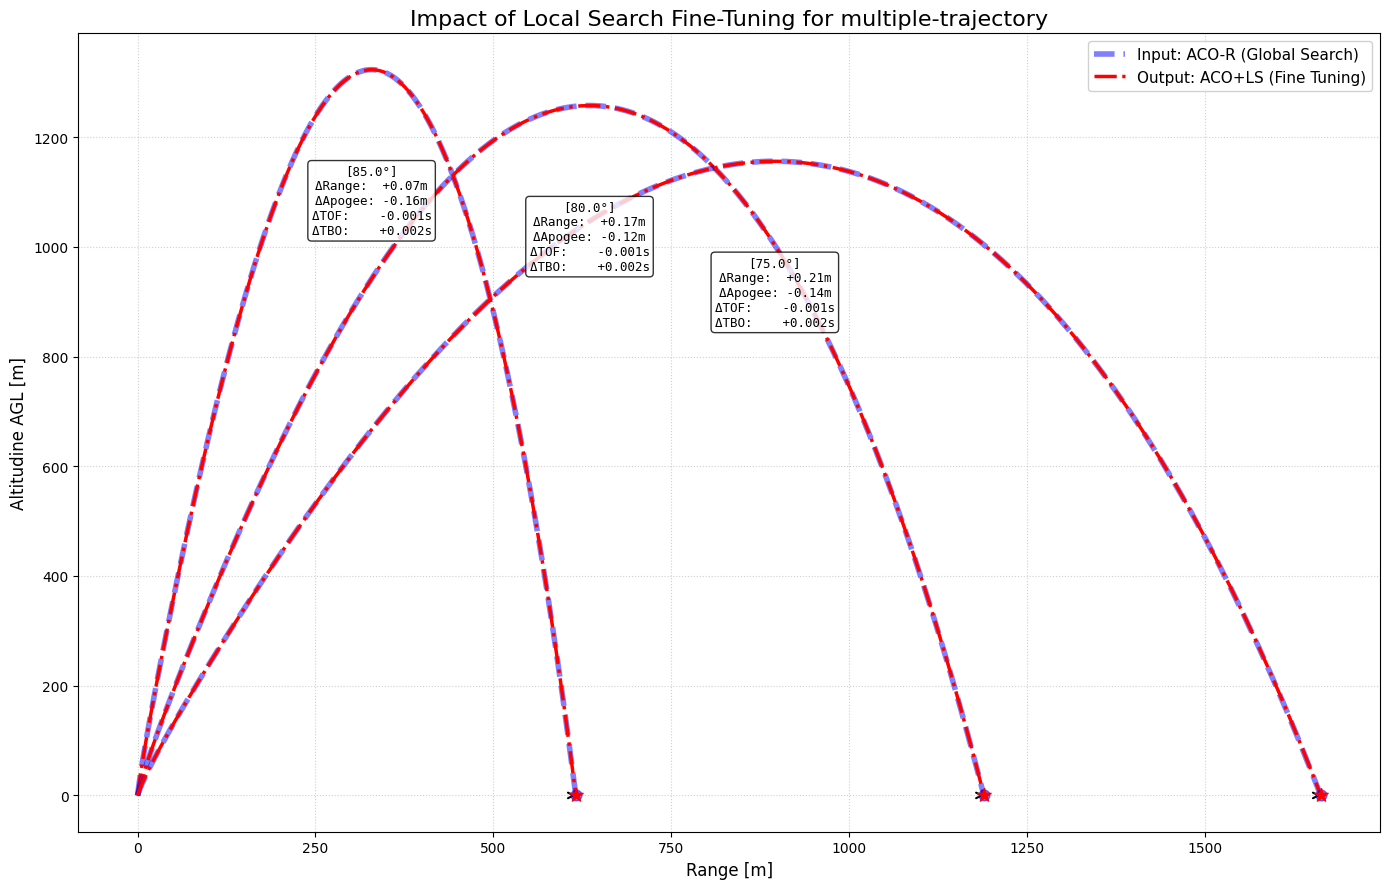

In [28]:
best_vector_aco = optimizer.archive_X[0] 
best_params_aco = dict(zip(optimizer.var_names, best_vector_aco))

d_tbo = ls_best_params['burn_time'] - best_params_aco['burn_time']

rocket_aco = factory.create_rocket(best_params_aco)
rocket_ls = factory.create_rocket(ls_best_params)


plt.figure(figsize=(14, 9))

handle_aco = None
handle_ls = None

for scen_name, scen_config in evaluator.triple_scenarios.items():
    angle = scen_config['fixed_launch_angle']
    

    flight_aco = Flight(rocket=rocket_aco, environment=evaluator.env, rail_length=factory.rail_length, 
                        inclination=angle, heading=90, terminate_on_apogee=False)
    

    flight_ls = Flight(rocket=rocket_ls, environment=evaluator.env, rail_length=factory.rail_length, 
                       inclination=angle, heading=90, terminate_on_apogee=False)
    

    r_aco = np.sqrt(flight_aco.x[:,1]**2 + flight_aco.y[:,1]**2)
    z_aco = flight_aco.z[:,1] - evaluator.env.elevation
    r_ls = np.sqrt(flight_ls.x[:,1]**2 + flight_ls.y[:,1]**2)
    z_ls = flight_ls.z[:,1] - evaluator.env.elevation
    

    dx = r_ls[-1] - r_aco[-1]
    dz_apogee = np.max(z_ls) - np.max(z_aco)
    d_tof = flight_ls.t_final - flight_aco.t_final # Delta Time of Flight
    
 
    # ACO (Input)
    l1, = plt.plot(r_aco, z_aco, color='blue', linestyle='--', linewidth=4, alpha=0.5)
    
    # LS (Output)
    l2, = plt.plot(r_ls, z_ls, color='red', linestyle='-.', linewidth=2.5, alpha=1.0)
    

    if handle_aco is None:
        handle_aco = l1
        handle_ls = l2
    
    # --- Markers ---
    # Start (ACO)
    plt.scatter(r_aco[-1], 0, color='blue', s=60, marker='o', alpha=0.5, zorder=5)
    # End (LS)
    plt.scatter(r_ls[-1], 0, color='red', s=100, marker='*', zorder=6)
    
 
    idx_apo = np.argmax(z_ls)
    text_x = r_ls[idx_apo]
    text_y = z_ls[idx_apo] - 300 
    
    info_text = (
        f"[{angle}°]\n"
        f"ΔRange:  {dx:+.2f}m\n"
        f"ΔApogee: {dz_apogee:+.2f}m\n"
        f"ΔTOF:    {d_tof:+.3f}s\n"
        f"ΔTBO:    {d_tbo:+.3f}s"
    )
    
    plt.text(text_x, text_y, info_text, 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8),
             ha='center', fontsize=9, family='monospace')
    
    plt.annotate("", xy=(r_ls[-1], 0), xytext=(r_aco[-1], 0),
                 arrowprops=dict(arrowstyle="->", color='black', lw=1.5))

plt.title("Impact of Local Search Fine-Tuning for multiple-trajectory", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitudine AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.legend([handle_aco, handle_ls], 
           ['Input: ACO-R (Global Search)', 'Output: ACO+LS (Fine Tuning)'], 
           loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

## Binary GA

In [29]:
try:
    from optimizer.binary_GA import BinaryGA
    print("BinaryGA module imported successfully.")
except ImportError:
    print("Error: BinaryGA module not found.")

print("\nStarting Multi-Trajectory Optimization (Binary GA)...")

# ------------------------------------------------------------------------------
# 1. CONFIGURATION AND INSTANTIATION
# Initialize the Genetic Algorithm using the shared configuration files.
# ------------------------------------------------------------------------------
optimizer_ga = BinaryGA(ACO_PARAMS_FILE, CONSTRAINTS_FILE)

# ------------------------------------------------------------------------------
# 2. INITIALIZATION (GENERATION 0)
# Generate the initial random population.
# IMPORTANT: We pass 'fitness_function_triple' to evaluate against all 3 scenarios.
# ------------------------------------------------------------------------------
print(f"   Population Size: {optimizer_ga.pop_size}")
print(f"   Bits per Parameter: {optimizer_ga.bits_per_param}")
print("   Initializing Random Population...")

optimizer_ga.initialize(fitness_function_triple)

# Retrieve baseline performance (best random guess)
_, best_fit_ga_start = optimizer_ga.get_best_solution()
print(f"   Best Random Start Fitness (GA): {best_fit_ga_start:.4f}")

# ------------------------------------------------------------------------------
# 3. MAIN OPTIMIZATION LOOP
# ------------------------------------------------------------------------------
start_time_ga = time.time()
best_fitness_history_ga = []

# Initialize counters
# The initial population evaluation consumes 'pop_size' function calls
call_counter_ga = optimizer_ga.pop_size
generation = 0

print(f"   Budget: {max_calls} function calls")

while call_counter_ga < max_calls:
    generation += 1
    
    # Execute one full generation (Selection -> Crossover -> Mutation -> Evaluation)
    # Using the multi-objective fitness function
    current_best_fit = optimizer_ga.optimize_step(fitness_function_triple)
    best_fitness_history_ga.append(current_best_fit)
    
    # Update function call counter
    # We assume the entire population is re-evaluated for simplicity in tracking
    calls_in_gen = optimizer_ga.pop_size
    call_counter_ga += calls_in_gen
    
    # Periodic Logging
    if generation % 10 == 0:
        print(f"   Gen: {generation:3d} | Calls: {call_counter_ga:5d} | Best Fit: {current_best_fit:.4f}")

# ------------------------------------------------------------------------------
# RESULTS RETRIEVAL
# ------------------------------------------------------------------------------
ga_time = time.time() - start_time_ga

# Retrieve final results into distinct variables to avoid overwriting ACO results
best_params_ga, best_score_ga = optimizer_ga.get_best_solution()

print(f"\nMulti-Trajectory GA completed in {ga_time:.2f} s.")
print(f"   Final GA Best Fitness: {best_score_ga:.4f}")

BinaryGA module imported successfully.

Starting Multi-Trajectory Optimization (Binary GA)...
   Population Size: 50
   Bits per Parameter: 16
   Initializing Random Population...
   Best Random Start Fitness (GA): 94.8928
   Budget: 4000 function calls
   Calls: 5000 | Current Fit: 383.2650
   Gen:  10 | Calls:   550 | Best Fit: 16.4772
   Calls: 5500 | Current Fit: 12.7820
   Gen:  20 | Calls:  1050 | Best Fit: 2.5513
   Calls: 6000 | Current Fit: 9.4621
   Gen:  30 | Calls:  1550 | Best Fit: 1.9892
   Calls: 6500 | Current Fit: 3.1318
   Gen:  40 | Calls:  2050 | Best Fit: 1.6050
   Calls: 7000 | Current Fit: 9.0280
   Gen:  50 | Calls:  2550 | Best Fit: 1.2662
   Gen:  60 | Calls:  3050 | Best Fit: 1.2649
   Gen:  70 | Calls:  3550 | Best Fit: 1.2420
   Calls: 8000 | Current Fit: 20.5081

Multi-Trajectory GA completed in 58109.99 s.
   Final GA Best Fitness: 1.2149


In [30]:
rocket_ga = factory.create_rocket(best_params_ga)

scenarios_data_ga = []


for key, val in evaluator.triple_scenarios.items():
    angle = val['fixed_launch_angle']
    target = val['target']
    
    print(f" Scenario {key} (Angle: {angle}°)")
    
    try:

        flight_ga = Flight(
            rocket=rocket_ga,
            environment=evaluator.env,
            rail_length=factory.rail_length,
            inclination=angle,
            heading=90,
            terminate_on_apogee=False
        )

        r_ga_profile = np.sqrt(flight_ga.x[:, 1]**2 + flight_ga.y[:, 1]**2)
        z_ga_profile = flight_ga.z[:, 1] - evaluator.env.elevation
        
        apogee_ga = flight_ga.apogee - evaluator.env.elevation
        range_ga = r_ga_profile[-1]
        
        print(f"      GA Apogee: {apogee_ga:.2f} m")
        print(f"      GA Range:  {range_ga:.2f} m")
        

        scenarios_data_ga.append({
            "name": key,
            "angle": angle,
            "flight": flight_ga,
            "r_profile": r_ga_profile,
            "z_profile": z_ga_profile,
            "target_vals": target
        })
        
    except Exception as e:
        print(f"     Error GA: {e}")


 Scenario scenario_1 (Angle: 85.0°)
      GA Apogee: 1322.73 m
      GA Range:  615.07 m
 Scenario scenario_2 (Angle: 80.0°)
      GA Apogee: 1257.20 m
      GA Range:  1192.26 m
 Scenario scenario_3 (Angle: 75.0°)
      GA Apogee: 1155.17 m
      GA Range:  1667.09 m


In [31]:
print("\n" + "="*50)
print(f" RESULTS OPTIMIZATION BINARY GA")
print("="*50)
print(f"Final Fitness: {best_score_ga:.6f}")
print("-" * 50)
print(f"{'PARAMETER':<25} | {'VALUE':<15}")
print("-" * 50)

for key, val in best_params_ga.items():
    print(f"{key:<25} | {val:.4f}")

print("="*50)


 RESULTS OPTIMIZATION BINARY GA
Final Fitness: 1.214899
--------------------------------------------------
PARAMETER                 | VALUE          
--------------------------------------------------
radius                    | 0.0631
body_length               | 2.0117
nose_length               | 0.5577
fin_span                  | 0.1381
fin_root_chord            | 0.3246
fin_tip_chord             | 0.1588
fin_sweep_angle           | 11.5942
fin_distance_from_base    | 0.0369
total_impulse             | 2905.3330
burn_time                 | 4.6254
launch_angle              | 87.7806


Generating Unified Plot for Binary GA...


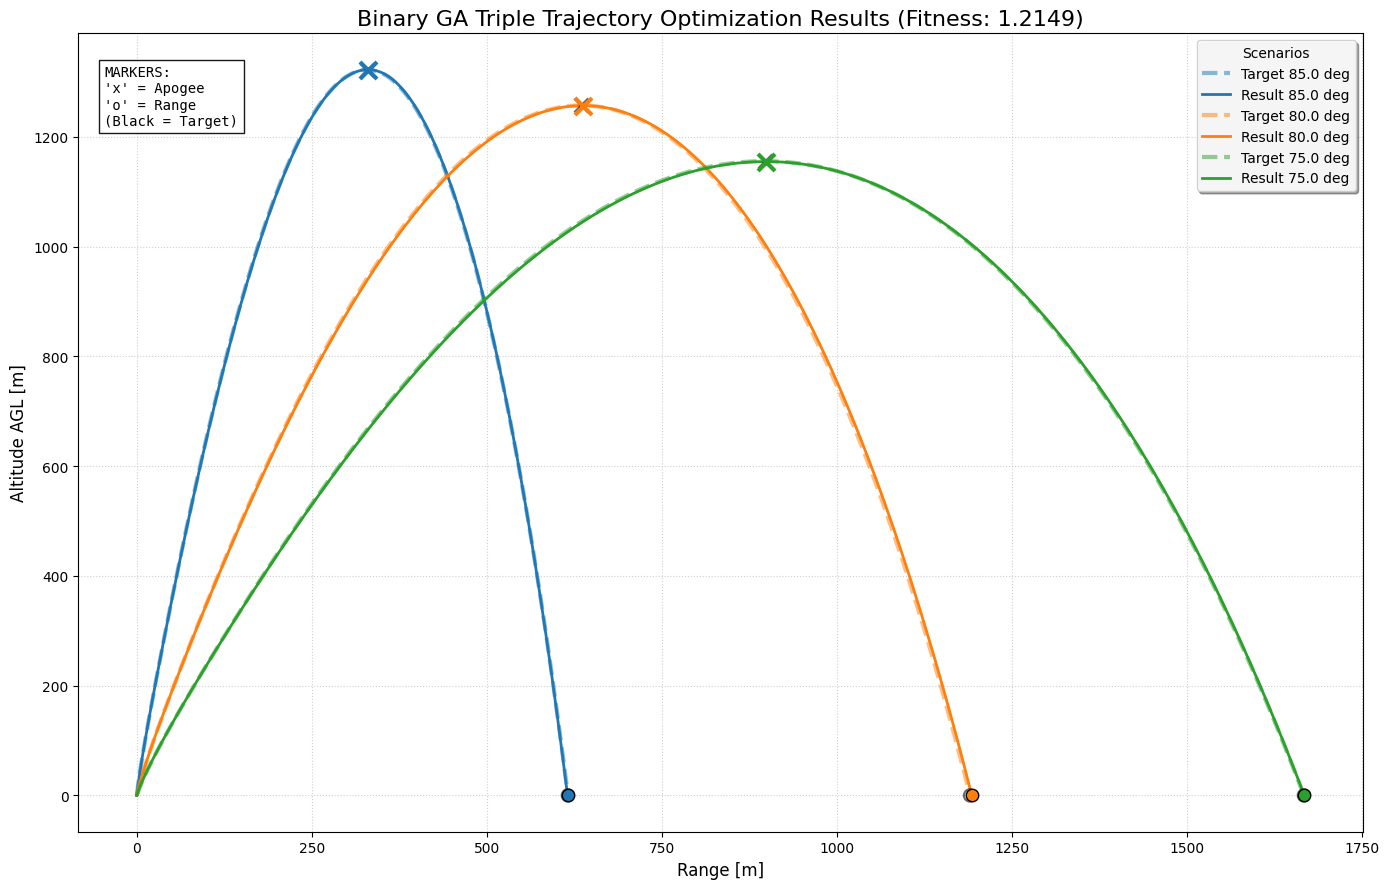

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from rocketpy import Flight

# ------------------------------------------------------------------------------
# TRIPLE TRAJECTORY VISUALIZATION (BINARY GA RESULTS)
# ------------------------------------------------------------------------------
# Contract:
# 1. Initialize a unified figure.
# 2. Iterate through 'scenarios_data_ga' containing Binary GA flight results.
# 3. Re-simulate or extract Target (Golden) flight data for comparison.
# 4. Plot trajectories:
#    - Target: Dashed line (Background).
#    - Result: Solid line (Foreground).
#    - Colors: Distinct per scenario (Blue=85, Orange=80, Green=75).
# 5. Plot Markers:
#    - Apogee ('x') and Impact ('o').
#    - Targets are marked in Black for visual distinction.
# ------------------------------------------------------------------------------

# --- Figure Setup ---
plt.figure(figsize=(14, 9))

# Standard colors to distinguish the 3 scenarios
# 85 deg = Blue, 80 deg = Orange, 75 deg = Green
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

# Base elevation
base_elevation = evaluator.env.elevation

print("Generating Unified Plot for Binary GA...")

# Lists to store legend handles manually
custom_lines = []
custom_labels = []

# --- Loop through Scenarios ---
for i, data in enumerate(scenarios_data_ga):
    color = colors[i]
    angle = data['angle']
    
    # --- Data Extraction ---
    
    # 1. GA Result (Optimized)
    flight_ga = data['flight']
    r_ga = np.sqrt(flight_ga.x[:,1]**2 + flight_ga.y[:,1]**2)
    z_ga = flight_ga.z[:,1] - base_elevation
    
    # 2. Target Data (Golden Rocket)
    # Check if golden flight data is already attached, otherwise simulate it
    if 'golden_flight' in data:
         flight_golden = data['golden_flight']
    else:
        # Re-simulate Golden Rocket for this angle to get the reference line
        golden_rocket = factory.create_rocket(missile_config['golden_rocket'])
        flight_golden = Flight(
            rocket=golden_rocket, 
            environment=evaluator.env, 
            rail_length=factory.rail_length, 
            inclination=angle, 
            heading=90, 
            terminate_on_apogee=False,
            verbose=False
        )

    r_tgt = np.sqrt(flight_golden.x[:,1]**2 + flight_golden.y[:,1]**2)
    z_tgt = flight_golden.z[:,1] - base_elevation

    # --- Plotting Lines ---
    
    # Target: Dashed, Thicker, Semi-transparent
    line_tgt, = plt.plot(r_tgt, z_tgt, color=color, linestyle='--', linewidth=3.0, alpha=0.5)
    
    # Result (GA): Solid, Standard width
    line_res, = plt.plot(r_ga, z_ga, color=color, linestyle='-', linewidth=2.0)
    
    # Append to custom legend list
    custom_lines.append(line_tgt)
    custom_labels.append(f"Target {angle} deg")
    custom_lines.append(line_res)
    custom_labels.append(f"Result {angle} deg")

    # --- Plotting Markers ---
    
    idx_tgt = np.argmax(z_tgt)
    idx_ga = np.argmax(z_ga)
    
    # Apogee Markers (x)
    # Target: Black Cross (for contrast)
    plt.scatter(r_tgt[idx_tgt], z_tgt[idx_tgt], color="black", marker='x', s=100, linewidth=2, zorder=5, alpha=0.6)
    # GA: Colored Cross
    plt.scatter(r_ga[idx_ga], z_ga[idx_ga], color=color, marker='x', s=150, linewidth=3, zorder=6)
    
    # Impact/Range Markers (o)
    # Target: Black Hollow Circle
    plt.scatter(r_tgt[-1], 0, color="black", marker='o', s=80, facecolors='none', edgecolors="black", linewidth=1.5, zorder=5, alpha=0.6)
    # GA: Colored Filled Circle
    plt.scatter(r_ga[-1], 0, color=color, marker='o', s=80, edgecolors='black', zorder=6)

# --- Decorations ---
plt.title(f"Binary GA Triple Trajectory Optimization Results (Fitness: {best_score_ga:.4f})", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitude AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Main Legend (Lines)
plt.legend(custom_lines, custom_labels, loc='upper right', framealpha=0.9, shadow=True, fontsize=10, title="Scenarios")

# Marker Legend Box (Top Left)
marker_legend_text = (
    "MARKERS:\n"
    "'x' = Apogee\n"
    "'o' = Range\n"
    "(Black = Target)"
)
plt.text(0.02, 0.96, marker_legend_text, 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'),
         verticalalignment='top', fontsize=10, family='monospace')

plt.tight_layout()
plt.show()

In [33]:
#draw_detailed_rocket_3d(best_params_ga)

In [34]:
headers_ga = ["Metric"]

for data in scenarios_data_ga:
    angle = int(data['angle'])
    headers_ga.append(f"Target ({angle}°)")
    headers_ga.append(f"Binary GA ({angle}°)")
    headers_ga.append(f"Diff ({angle}°)")

row_apogee_ga = ["Apogee (m)"]
row_range_ga  = ["Range (m)"]
row_tof_ga    = ["TOF (s)"]
row_tbo_ga    = ["TBO (s)"]

for data in scenarios_data_ga:

    flight_opt = data['flight'] 
    targets = data['target_vals']
    
    opt_apogee = flight_opt.apogee - evaluator.env.elevation
    opt_range = np.sqrt(flight_opt.x[:,1][-1]**2 + flight_opt.y[:,1][-1]**2)
    
    opt_tof = flight_opt.t_final
    opt_tbo = best_params_ga['burn_time'] 
    
    tgt_apogee = targets['apogee']
    tgt_range = targets['range']
    tgt_tof = targets['flight_time']
    tgt_tbo = targets['burn_time']
    
    # Apogeo
    row_apogee_ga.extend([tgt_apogee, opt_apogee, (opt_apogee - tgt_apogee)])
    # Range
    row_range_ga.extend([tgt_range, opt_range, (opt_range - tgt_range)])
    # TOF
    row_tof_ga.extend([tgt_tof, opt_tof, (opt_tof - tgt_tof)])
    # TBO
    row_tbo_ga.extend([tgt_tbo, opt_tbo, (opt_tbo - tgt_tbo)])


df_flat_ga = pd.DataFrame([row_apogee_ga, row_range_ga, row_tof_ga, row_tbo_ga], columns=headers_ga)


pd.options.display.float_format = '{:,.2f}'.format

print("\n Final Result Table BINARY GA (Triple Trajectory)")
print("="*100)
display(df_flat_ga)

#df_flat_ga.to_csv("../results/triple_trajectory/Binary_GA_results_trajectories.csv", index=False)


 Final Result Table BINARY GA (Triple Trajectory)


,Metric,Target (85°),Binary GA (85°),Diff (85°),Target (80°),Binary GA (80°),Diff (80°),Target (75°),Binary GA (75°),Diff (75°)
0,Apogee (m),"1,322.30","1,322.73",0.43,"1,257.50","1,257.20",-0.30,"1,156.00","1,155.17",-0.83
1,Range (m),615.60,615.07,-0.53,"1,189.90","1,192.26",2.36,"1,666.50","1,667.09",0.59
2,TOF (s),35.60,35.69,0.09,34.80,34.87,0.07,33.50,33.52,0.02
3,TBO (s),4.50,4.63,0.13,4.50,4.63,0.13,4.50,4.63,0.13


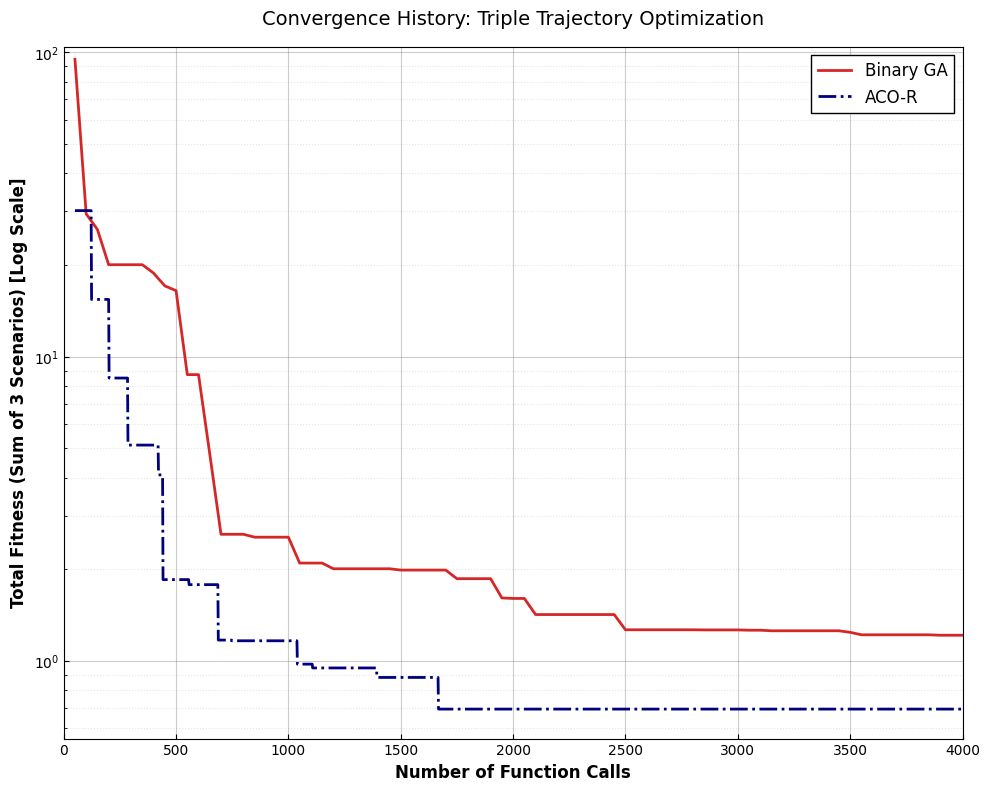

In [35]:
# ------------------------------------------------------------------------------
# CONVERGENCE HISTORY PLOT (TRIPLE TRAJECTORY)
# ------------------------------------------------------------------------------

# --- 1. Parameters & Data Setup ---
# Retrieve algorithmic parameters from loaded configs
k_aco = aco_config['aco']['archive_size']           # 50
m_aco = aco_config['aco']['new_solutions']          # 2
pop_ga = aco_config['binary_ga']['population_size'] # 50

# Visualization Target: Use the global budget limit
TARGET_CALLS = max_calls 

# Convert history lists to numpy arrays
# are populated from the previous multi-trajectory runs.
y_aco = np.array(best_fitness_history)
y_ga = np.array(best_fitness_history_ga)

# Generate original X-Axis (Function Calls)
# ACO updates every 'm' calls; GA updates every 'pop' calls.
x_aco = np.arange(len(y_aco)) * m_aco + k_aco
x_ga = np.arange(len(y_ga)) * pop_ga + pop_ga

# --- 2. Data Extension ("Holding the last value") ---
# If an algorithm finished early or data is shorter than budget,
# extend the line horizontally to the target limit.

# Extend ACO
if x_aco[-1] < TARGET_CALLS:
    x_aco = np.append(x_aco, TARGET_CALLS) 
    y_aco = np.append(y_aco, y_aco[-1])    

# Extend GA 
if x_ga[-1] < TARGET_CALLS:
    x_ga = np.append(x_ga, TARGET_CALLS)
    y_ga = np.append(y_ga, y_ga[-1])

# --- 3. Plot Setup ---
plt.figure(figsize=(10, 8))

# --- 4. Plotting ---

# Binary GA (Solid Red)
plt.semilogy(x_ga, y_ga, color='#d62728', linestyle='-', linewidth=2, label='Binary GA')

# ACO-R (Dash-dot Blue)
plt.semilogy(x_aco, y_aco, color='#000080', linestyle='-.', linewidth=2, label='ACO-R')

# --- 5. Axis Configuration ---

# Force X limit to budget
plt.xlim(0, TARGET_CALLS)

# Dynamic Y Limits for Triple Trajectory
# Since fitness is the sum of 3 errors, values are higher than single case.
y_all = np.concatenate([y_aco, y_ga])
y_min = np.min(y_all)
y_max = np.max(y_all)

# Set limits with padding. 
# y_max is capped to avoid scaling issues with initial random outliers.
plt.ylim(y_min * 0.8, y_max * 1.1)

# --- 6. Formatting ---
plt.xlabel('Number of Function Calls', fontsize=12, fontweight='bold')
plt.ylabel('Total Fitness (Sum of 3 Scenarios) [Log Scale]', fontsize=12, fontweight='bold')
plt.title('Convergence History: Triple Trajectory Optimization', fontsize=14, y=1.02)

# Grid
plt.grid(True, which="major", ls="-", alpha=0.4, color='gray')
plt.grid(True, which="minor", ls=":", alpha=0.2, color='gray')

# Legend
plt.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1, 
           loc='upper right', fontsize=12)

# Tick styling
plt.tick_params(axis='both', direction='in', which='both', labelsize=10)

plt.tight_layout()
plt.show()

## Final Comparison

In [ ]:
# ==============================================================================
# 1. SETUP AND RE-SIMULATION (Ensure Data Consistency)
# ==============================================================================

# Retrieve Optimal Parameters
# If ACO Base parameters are not explicitly saved, retrieve them from the optimizer archive
if 'best_params_aco' not in locals():
    best_params_aco = dict(zip(optimizer.var_names, optimizer.archive_X[0]))

# Define designs to be tested
designs_to_test = {
    "Target (Golden)": golden_params,
    "ACO-R (Base)": best_params_aco,
    "ACO-R + LS (Hybrid)": ls_best_params,
    "Binary GA": best_params_ga
}

# Dictionary to store simulation metrics
# Structure: results_db[algorithm][scenario_angle] = {range, apogee, tof, tbo}
results_db = {name: {} for name in designs_to_test.keys()}

print("Calculating final metrics for all algorithms...")

for alg_name, params in designs_to_test.items():
    # Instantiate Rocket
    rocket = factory.create_rocket(params)
    tbo_val = params['burn_time'] # Nominal TBO
    
    # Loop through scenarios defined in the evaluator
    for scen_name, scen_config in evaluator.triple_scenarios.items():
        angle = scen_config['fixed_launch_angle']
        
        # Execute Simulation
        try:
            flight = Flight(
                rocket=rocket, environment=evaluator.env, rail_length=factory.rail_length,
                inclination=angle, heading=90, terminate_on_apogee=False, verbose=False
            )
            
            # Extract Data
            r = np.sqrt(flight.x[:,1][-1]**2 + flight.y[:,1][-1]**2)
            z = flight.apogee - evaluator.env.elevation
            tof = flight.t_final
            
            results_db[alg_name][angle] = {
                'Range': r, 'Apogee': z, 'TOF': tof, 'TBO': tbo_val
            }
        except:
            # Handle simulation failures (e.g., instability)
            results_db[alg_name][angle] = {'Range': 0, 'Apogee': 0, 'TOF': 0, 'TBO': 0}

print("Data calculation complete.")

# ==============================================================================
# 2. TABLE 1: GLOBAL PERFORMANCE (Executive Summary)
# ==============================================================================
summary_data = []

# Execution Times (Assuming variables exist in the notebook scope)
# Ensure keys match designs_to_test
times = {
    "ACO-R (Base)": execution_time,
    "ACO-R + LS (Hybrid)": execution_time + ls_time,
    "Binary GA": ga_time
}

# Fitness Scores
scores = {
    "ACO-R (Base)": best_score, 
    "ACO-R + LS (Hybrid)": ls_best_fitness,
    "Binary GA": best_score_ga
}

# Algorithms to include in summary
algorithms = ["ACO-R (Base)", "ACO-R + LS (Hybrid)", "Binary GA"]

for alg in algorithms:
    # Initialize error accumulators
    total_range_err = 0
    total_apogee_err = 0
    total_tof_err = 0
    total_tbo_err = 0
    
    # Loop through the 3 scenarios (85, 80, 75 degrees)
    for angle in [85.0, 80.0, 75.0]:
        tgt = results_db["Target (Golden)"][angle]
        act = results_db[alg][angle]
        
        # Sum absolute errors
        total_range_err += abs(act['Range'] - tgt['Range'])
        total_apogee_err += abs(act['Apogee'] - tgt['Apogee'])
        total_tof_err += abs(act['TOF'] - tgt['TOF'])
        total_tbo_err += abs(act['TBO'] - tgt['TBO'])
    
    # Calculate averages and append row
    summary_data.append({
        "Algorithm": alg,
        "Total Fitness": scores.get(alg, 0),
        "Exec Time (s)": times.get(alg, 0),
        "Avg Range Err (m)": total_range_err / 3,
        "Avg Apogee Err (m)": total_apogee_err / 3,
        "Avg TOF Err (s)": total_tof_err / 3,
        "Avg TBO Err (s)": total_tbo_err / 3
    })

df_summary = pd.DataFrame(summary_data)

# ==============================================================================
# 4. TABLE 3: PHYSICAL DESIGN COMPARISON (Parameters)
# ==============================================================================
param_data = []
param_keys = list(golden_params.keys())

# Ensure random_best_params is available
if 'random_best_params' not in locals():
    random_best_params = {} 

for key in param_keys:
    row = {
        "Parameter": key,
        "Target (Golden)": golden_params.get(key),
        "Random Start (ACO-R)": random_best_params.get(key, 0.0),
        "Optimized (ACO-R)": best_params_aco.get(key),
        "ACO-R + LS": ls_best_params.get(key),
        "Optimized (GA)": best_params_ga.get(key)
    }
    param_data.append(row)

df_params = pd.DataFrame(param_data)


# ==============================================================================
# 5. VISUALIZATION AND EXPORT
# ==============================================================================
pd.options.display.float_format = '{:,.3f}'.format

print("\n" + "="*80)
print(f"TABLE 1: GLOBAL PERFORMANCE (Executive Summary)")
print("="*80)
display(df_summary)
#df_summary.to_csv("../results/triple_trajectory/final_performance_triple.csv", index=False)


print("\n" + "="*80)
print(f"TABLE 3: DESIGN PARAMETER COMPARISON (Physical Solution)")
print("="*80)
display(df_params)
# df_params.to_csv("../results/triple_trajectory/triple_trajectory_parameters.csv", index=False)

Calculating final metrics for all algorithms...
Data calculation complete.

TABLE 1: GLOBAL PERFORMANCE (Executive Summary)


,Algorithm,Total Fitness,Exec Time (s),Avg Range Err (m),Avg Apogee Err (m),Avg TOF Err (s),Avg TBO Err (s)
0,ACO-R (Base),0.695,"1,594.564",1.321,0.287,0.052,0.051
1,ACO-R + LS (Hybrid),0.648,"1,864.923",1.218,0.209,0.053,0.049
2,Binary GA,1.215,"58,109.994",1.164,0.485,0.080,0.125



TABLE 3: DESIGN PARAMETER COMPARISON (Physical Solution)


,Parameter,Target (Golden),Random Start (ACO-R),Optimized (ACO-R),ACO-R + LS,Optimized (GA)
0,radius,0.065,0.086,0.061,0.061,0.063
1,body_length,2.100,1.396,2.390,2.390,2.012
2,nose_length,0.650,0.428,0.412,0.411,0.558
3,fin_span,0.180,0.196,0.249,0.249,0.138
4,fin_root_chord,0.350,0.208,0.278,0.278,0.325
5,fin_tip_chord,0.120,0.167,0.126,0.126,0.159
6,fin_sweep_angle,30.000,42.908,38.654,38.896,11.594
7,fin_distance_from_base,0.000,0.029,0.000,0.000,0.037
8,total_impulse,"3,200.000","3,164.510","3,253.825","3,253.659","2,905.333"
9,burn_time,4.500,4.573,4.449,4.451,4.625
